# 15 — LSAR Full-Pol Observables & Eigen Analysis

This module computes **full-polarimetric observables from the authoritative Module 06 spatial subset**.

### What is improved in this revision

- Preserves the existing scientific workflow and the corrected complex **C3 → T3** transformation.
- Uses the GCOV `MASK` consistently through the polarimetric reconstruction.
- Uses **adaptive memory handling**:
  - small AOIs (up to `1024 × 1024`) are processed as one block;
  - larger AOIs are processed tile-by-tile without changing the scientific subset.
- The complete source HDF5 product remains on disk; only the current tile is loaded into memory.
- Final `Span`, `Entropy H`, and `Anisotropy A` rasters are retained as `float32` arrays.
- The authoritative Module 06 subset is **not changed**.

> **Important:** `1024 × 1024` is a practical default, not a mathematical guarantee of zero memory errors. Actual memory demand also depends on available RAM and the NumPy/LAPACK backend.

## Scientific workflow

`L2 GCOV HDF5 → six full-pol covariance terms → MASK==0 → Hermitian C3 → standard C3 → Pauli T3 → eigen analysis → Span / H / A`

For LSAR full polarimetry the module uses:

- diagonal terms: `HHHH`, `HVHV`, `VVVV`
- complex off-diagonal terms: `HHHV`, `HHVV`, `HVVV`

The complex off-diagonal terms are retained as complex quantities; they are **not replaced by magnitudes**.

In [1]:
# Module 15 — setup and adaptive-memory controls

import gc
import numpy as np
import matplotlib.pyplot as plt

from nisar_utils.config import load_config
from nisar_utils.polarimetric_io import (
    load_detected_mode,
    load_branch_terms,
    FULL_POL_TERMS,
    read_terms_for_subset,
    apply_mask_to_terms,
    subset_slices,
)
from nisar_utils.gcov import read_gcov_mask
from nisar_utils.polarimetry import (
    covariance_hermitian_from_terms,
    nisar_c3_to_standard_c3,
    standard_c3_to_t3,
    eigen_analysis,
)

cfg = load_config()
mode = load_detected_mode(cfg)

if mode["polarimetric_mode"] != "LSAR_FULL_POL":
    print("SKIPPED:", mode["polarimetric_mode"])
else:
    sp = {
        "r0": int(cfg["spatial_subset"]["r0"]),
        "r1": int(cfg["spatial_subset"]["r1"]),
        "c0": int(cfg["spatial_subset"]["c0"]),
        "c1": int(cfg["spatial_subset"]["c1"]),
    }

    nrows = sp["r1"] - sp["r0"]
    ncols = sp["c1"] - sp["c0"]
    npix = nrows * ncols

    # Practical workshop default. Larger AOIs are tiled automatically.
    TILE_ROWS = 1024
    TILE_COLS = 1024
    WHOLE_AOI_MAX_PIXELS = TILE_ROWS * TILE_COLS

    print("LSAR full-pol branch detected")
    print("Frequency:", mode["polarimetric_frequency"])
    print("Authoritative Module 06 subset:", sp)
    print(f"AOI size: {nrows:,} rows × {ncols:,} columns = {npix:,} pixels")
    print(f"Whole-AOI threshold: {WHOLE_AOI_MAX_PIXELS:,} pixels")
    print(f"Large-AOI tile: {TILE_ROWS} × {TILE_COLS}")


LSAR full-pol branch detected
Frequency: frequencyA
Authoritative Module 06 subset: {'r0': 7056, 'r1': 12653, 'c0': 6459, 'c1': 11507}
AOI size: 5,597 rows × 5,048 columns = 28,253,656 pixels
Whole-AOI threshold: 1,048,576 pixels
Large-AOI tile: 1024 × 1024


In [2]:
# Module 15 — one scientific processing block

def process_fullpol_block(block_sp):
    """
    Read one spatial block, apply MASK==0, reconstruct C3/T3,
    and return Span, Entropy H and Anisotropy A as float32.
    """
    data = read_terms_for_subset(
        cfg["nisar_file"],
        mode["polarimetric_base"],
        FULL_POL_TERMS,
        block_sp,
    )

    rs, cs = subset_slices(block_sp)

    # The same GCOV MASK window is applied to all covariance terms.
    with __import__("h5py").File(cfg["nisar_file"], "r") as f:
        invalid_mask, mask_arr = read_gcov_mask(
            f,
            mode["polarimetric_base"],
            rs.start, rs.stop,
            cs.start, cs.stop,
        )

    data = apply_mask_to_terms(data, invalid_mask)

    masked_count = int(np.count_nonzero(invalid_mask))

    # Build and transform sequentially so large intermediate matrices can
    # be released before the next one is created.
    Craw = covariance_hermitian_from_terms(data)
    del data

    Cstd = nisar_c3_to_standard_c3(Craw)
    del Craw

    T3 = standard_c3_to_t3(Cstd)
    del Cstd

    # eigen_analysis explicitly handles NaN-containing matrices produced by
    # MASK==0 and restores NaN to all affected outputs.
    e = eigen_analysis(T3, clip_negative=False)
    del T3

    span = np.asarray(e["span"], dtype=np.float32)
    entropy = np.asarray(e["entropy"], dtype=np.float32)
    anisotropy = np.asarray(e["anisotropy"], dtype=np.float32)

    del e, mask_arr, invalid_mask
    gc.collect()

    return span, entropy, anisotropy, masked_count


In [3]:
# Module 15 — adaptive execution

if mode["polarimetric_mode"] == "LSAR_FULL_POL":

    if npix <= WHOLE_AOI_MAX_PIXELS:
        # Small AOI: retain the simple participant workflow.
        print("\nProcessing mode: WHOLE AOI")
        print("This AOI is within the practical 1024 × 1024 workshop threshold.")

        data, sp_check, guard, mode_check = load_branch_terms(cfg, FULL_POL_TERMS)

        # Reuse the same masking/reconstruction logic, but avoid a second disk read.
        rs, cs = subset_slices(sp_check)
        with __import__("h5py").File(cfg["nisar_file"], "r") as f:
            invalid_mask, mask_arr = read_gcov_mask(
                f,
                mode["polarimetric_base"],
                rs.start, rs.stop,
                cs.start, cs.stop,
            )

        data = apply_mask_to_terms(data, invalid_mask)

        Craw = covariance_hermitian_from_terms(data)
        del data

        Cstd = nisar_c3_to_standard_c3(Craw)
        del Craw

        T3 = standard_c3_to_t3(Cstd)
        del Cstd

        e = eigen_analysis(T3, clip_negative=False)
        del T3

        span = np.asarray(e["span"], dtype=np.float32)
        entropy = np.asarray(e["entropy"], dtype=np.float32)
        anisotropy = np.asarray(e["anisotropy"], dtype=np.float32)

        masked_pixels = int(np.count_nonzero(invalid_mask))

        del e, mask_arr, invalid_mask
        gc.collect()

        processing_mode = "whole-AOI"

    else:
        # Large AOI: preserve the exact Module 06 subset, but process it in
        # independent windows. The source product is never copied in full.
        print("\nProcessing mode: ADAPTIVE TILED")
        print(
            f"AOI exceeds {WHOLE_AOI_MAX_PIXELS:,} pixels; "
            f"processing in {TILE_ROWS} × {TILE_COLS} tiles."
        )

        span = np.full((nrows, ncols), np.nan, dtype=np.float32)
        entropy = np.full((nrows, ncols), np.nan, dtype=np.float32)
        anisotropy = np.full((nrows, ncols), np.nan, dtype=np.float32)

        masked_pixels = 0
        tile_count = 0
        total_tiles = (
            (nrows + TILE_ROWS - 1) // TILE_ROWS
            * (ncols + TILE_COLS - 1) // TILE_COLS
        )

        for rr0 in range(sp["r0"], sp["r1"], TILE_ROWS):
            rr1 = min(rr0 + TILE_ROWS, sp["r1"])
            out_r0 = rr0 - sp["r0"]
            out_r1 = rr1 - sp["r0"]

            for cc0 in range(sp["c0"], sp["c1"], TILE_COLS):
                cc1 = min(cc0 + TILE_COLS, sp["c1"])
                out_c0 = cc0 - sp["c0"]
                out_c1 = cc1 - sp["c0"]

                tile_sp = {
                    "r0": rr0, "r1": rr1,
                    "c0": cc0, "c1": cc1,
                }

                tile_count += 1
                print(
                    f"Tile {tile_count}/{total_tiles}: "
                    f"rows {rr0}:{rr1}, cols {cc0}:{cc1}"
                )

                s, h, a, mcount = process_fullpol_block(tile_sp)

                span[out_r0:out_r1, out_c0:out_c1] = s
                entropy[out_r0:out_r1, out_c0:out_c1] = h
                anisotropy[out_r0:out_r1, out_c0:out_c1] = a

                masked_pixels += mcount

                del s, h, a
                gc.collect()

        processing_mode = "adaptive-tiled"

    print("\nProcessing complete.")
    print("Mode:", processing_mode)
    print("Exact Module 06 subset:", sp)
    print(f"MASK == 0 pixels: {masked_pixels:,}")

    for name, arr in [
        ("Span", span),
        ("Entropy H", entropy),
        ("Anisotropy A", anisotropy),
    ]:
        finite = np.isfinite(arr)
        if np.any(finite):
            vals = arr[finite]
            print(
                f"{name}: median={float(np.median(vals)):.6g}, "
                f"p05={float(np.percentile(vals, 5)):.6g}, "
                f"p95={float(np.percentile(vals, 95)):.6g}"
            )
        else:
            print(f"{name}: no valid pixels")



Processing mode: ADAPTIVE TILED
AOI exceeds 1,048,576 pixels; processing in 1024 × 1024 tiles.
Tile 1/35: rows 7056:8080, cols 6459:7483
Tile 2/35: rows 7056:8080, cols 7483:8507
Tile 3/35: rows 7056:8080, cols 8507:9531
Tile 4/35: rows 7056:8080, cols 9531:10555
Tile 5/35: rows 7056:8080, cols 10555:11507
Tile 6/35: rows 8080:9104, cols 6459:7483
Tile 7/35: rows 8080:9104, cols 7483:8507
Tile 8/35: rows 8080:9104, cols 8507:9531
Tile 9/35: rows 8080:9104, cols 9531:10555
Tile 10/35: rows 8080:9104, cols 10555:11507
Tile 11/35: rows 9104:10128, cols 6459:7483
Tile 12/35: rows 9104:10128, cols 7483:8507
Tile 13/35: rows 9104:10128, cols 8507:9531
Tile 14/35: rows 9104:10128, cols 9531:10555
Tile 15/35: rows 9104:10128, cols 10555:11507
Tile 16/35: rows 10128:11152, cols 6459:7483
Tile 17/35: rows 10128:11152, cols 7483:8507
Tile 18/35: rows 10128:11152, cols 8507:9531
Tile 19/35: rows 10128:11152, cols 9531:10555
Tile 20/35: rows 10128:11152, cols 10555:11507
Tile 21/35: rows 11152:121

## Interpretation

- **Span** is the total power represented by the Pauli/T3 coherency matrix.
- **Entropy H** follows the Cloude–Pottier eigenvalue probability formulation.
- **Anisotropy A** is computed from the second and third eigenvalues.
- Pixels where the GCOV `MASK == 0` are propagated as `NaN` rather than being interpreted as physical zero-power observations.

The tiled and whole-AOI paths use the **same covariance reconstruction, corrected C3→T3 transformation, and eigen-analysis functions**. Tiling changes memory usage, not the scientific formulation.

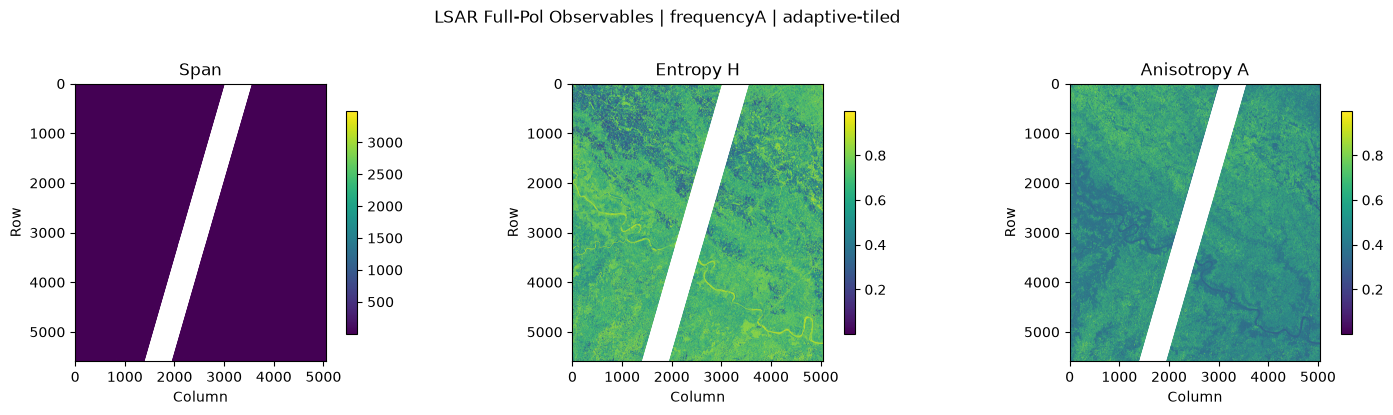

In [4]:
# Module 15 — visualization

if mode["polarimetric_mode"] == "LSAR_FULL_POL":
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    for aa, arr, title in zip(
        ax,
        [span, entropy, anisotropy],
        ["Span", "Entropy H", "Anisotropy A"],
    ):
        im = aa.imshow(arr, origin="upper")
        aa.set_title(title)
        aa.set_xlabel("Column")
        aa.set_ylabel("Row")
        plt.colorbar(im, ax=aa, shrink=0.8)

    fig.suptitle(
        f"LSAR Full-Pol Observables | {mode['polarimetric_frequency']} | "
        f"{processing_mode}",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


### Memory note

For a large real NISAR LSAR AOI such as approximately `5597 × 5048`, the old implementation attempted to allocate the full `3 × 3` complex T3 matrix at once. The revised module avoids that peak-memory pattern by processing only a `1024 × 1024` tile at a time.

A smaller AOI is therefore still the preferred workshop setting, but **large real-data AOIs no longer require the participant to manually redefine the authoritative Module 06 subset just to avoid a matrix-allocation failure**.